<a href="https://colab.research.google.com/github/muchammadwr/churn-at-fit.ly/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

## Business Understanding

### Background
Over the past two quarters, Fit.ly Tech has observed an increase in customer churn. Customer retention has become increasingly important as the cost of acquiring new customers continues to rise. As a result, leadership needs a clearer understanding of the patterns and potential factors associated with customer churn.

The available data comes from multiple sources, including user activity, customer support, and account information. Since these datasets were developed independently by different teams, they may use different conventions and structures. Therefore, the analysis will combine and assess these sources to identify meaningful patterns in customer engagement, support activity, and plan type.

The findings will be used to help Marketing and Product identify practical, evidence-based actions that can improve customer retention.


### Objective

To identify patterns and potential drivers of customer churn by analyzing customer engagement, support activity, and plan type, and translate these findings into practical, evidence-based actions that Marketing and Product teams can use to improve customer retention.



### Success Criteria

The analysis will be considered successful if it provides:

- A clear understanding of the current churn rate and how it has changed over the past two quarters.
- Identification of customer segments or behaviors associated with higher churn, particularly across engagement, support activity, and plan type.
- Identification of relevant KPIs that leadership can monitor to detect potential churn risks.
- Evidence-based findings that can be translated into practical actions for Marketing and Product.
- A set of measurable retention recommendations that can be evaluated in the following quarter.

A specific churn-reduction target, such as a 15% reduction, should be confirmed with senior leadership before being used as a formal business target.

### Analytical Questions (Optional)

1. What is the current customer churn rate, and how is churn distributed across the customer base?
2. How does customer engagement, measured by activity frequency and activity type, relate to customer churn?
3. How does customer support activity, including ticket frequency and resolution time, relate to customer churn?
4. How does customer churn vary across subscription plans and plan price levels?
5. What combinations of engagement, support activity, and subscription characteristics are associated with higher customer churn?

## Data Understanding

In [352]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [353]:
account_info_df = pd.read_csv("https://raw.githubusercontent.com/muchammadwr/churn-at-fit.ly/refs/heads/main/data/da_fitly_account_info.csv")
customer_support_df = pd.read_csv("https://raw.githubusercontent.com/muchammadwr/churn-at-fit.ly/refs/heads/main/data/da_fitly_customer_support.csv")
user_activity_df = pd.read_csv("https://raw.githubusercontent.com/muchammadwr/churn-at-fit.ly/refs/heads/main/data/da_fitly_user_activity.csv")

Fit.ly Tech uses several important data sources for the churn analysis, including account information, user activity, and customer support data. The account information contains customer details such as signup date, state, plan type, plan list price, and churn status. The user activity data records customer actions within the application and will be used to measure customer engagement. The customer support data contains information about support tickets, including ticket time, resolution time, and support channel, which will be used to assess customer support activity. These datasets are maintained independently by different teams and are updated daily, so the data will need to be reviewed and mapped using appropriate customer identifiers before being combined for analysis. The company does not currently plan to purchase additional external data or conduct surveys; therefore, this analysis will focus on the existing internal datasets to identify churn patterns and potential drivers across engagement, support activity, and plan type.

#### `account_info_df`

Information from stakeholder

Account info:
- Signup_date is the day the customer created their account
- State: currently we’re US only - we’ll need a think about our data structure when we
expand internationally, but we’re not thinking about that right now
- Plan types: I’d expect the different types of plan to be captured in the data, but you
might want to check. We have the following tiers: free, basic, pro or enterprise
- Plan list price: this is actual price paid
- Churn status: we mark people as churned once their subscription has been cancelled.

In [354]:
# Show 20 rows dataframe
account_info_df.sample(20)

,customer_id,email,state,plan,plan_list_price,churn_status
144,C10144,user10144@example.org,Vermont,Pro,56,NaN
194,C10194,user10194@example.net,Massachusetts,Basic,15,NaN
59,C10059,user10059@example.com,Rhode Island,Basic,29,Y
345,C10345,user10345@example.net,Florida,Free,0,Y
78,C10078,user10078@example.org,Kentucky,Enterprise,137,NaN
80,C10080,user10080@example.org,Delaware,Pro,64,NaN
54,C10054,user10054@example.com,Montana,Free,0,NaN
100,C10100,user10100@example.com,Tennessee,Enterprise,111,NaN
139,C10139,user10139@example.com,Missouri,Free,0,NaN
165,C10165,user10165@example.com,Tennessee,Enterprise,137,NaN


The `account_info_df` dataset provides an initial overview of customer account information. A random sample of 20 rows was examined from a dataset containing **7 features**: `customer_id`, `email`, `state`, `plan`, `plan_list_price`, and `churn_status`.


In [355]:
# Check dataframe information
account_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB


Data Information - `account_info_df`

* **`customer_id`**: Unique identifier for each customer. It contains **400 non-null values**, uses the `object` data type, and can be used to identify customers and connect account information with other datasets.

* **`email`**: Customer email address used as contact or customer-identification information. It contains **400 non-null values** and uses the `object` data type.

* **`state`**: U.S. state where the customer is located. It contains **400 non-null values** and uses the `object` data type. This feature can be used to analyze geographic patterns in customer behavior and churn.

* **`plan`**: Customer's subscription tier. It contains **400 non-null values** and uses the `object` data type. Based on the Product Manager's information, the expected plans are **Free, Basic, Pro, and Enterprise**.

* **`plan_list_price`**: The actual price paid by the customer for their subscription. It contains **400 non-null values** and uses the `int64` data type. This feature can be used to analyze customer revenue and compare monetary value across subscription plans.

* **`churn_status`**: Indicates whether a customer's subscription has been cancelled. It contains **114 non-null values** and uses the `object` data type. Based on the Product Manager's definition, `Y` represents a churned customer, while the **286 missing values** likely represent customers who have not been marked as churned.


In [356]:
# Check missing values
account_info_df.isna().sum()

,0
customer_id,0
email,0
state,0
plan,0
plan_list_price,0
churn_status,286


`churn_status` contains 286 missing values, while the other five features are complete. According to the stakeholder, these missing values represent customers who remain active, so they should not be treated as missing or invalid data during churn analysis.


In [357]:
# Check value null on churn status feature
account_info_df['churn_status'].value_counts(dropna=False)

,count
churn_status,
NaN,286
Y,114


The `churn_status` column contains **114 churned customers (`Y`)** and **286 customers who have not churned**, represented by missing values. Based on the stakeholder's explanation, these missing values indicate that the customer's subscription is still active and has not been cancelled.


In [358]:
# Check duplicate values
account_info_df.duplicated().sum()

np.int64(0)

There's no duplicate values

In [359]:
# Descriptive statistic
account_info_df.describe(include='all')

,customer_id,email,state,plan,plan_list_price,churn_status
count,400,400,400,400,400.000000,114
unique,400,400,50,4,NaN,1
top,C10383,user10383@example.com,Virginia,Basic,NaN,Y
freq,1,1,16,118,NaN,114
mean,NaN,NaN,NaN,NaN,43.965000,NaN
std,NaN,NaN,NaN,NaN,45.263348,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,26.000000,NaN
75%,NaN,NaN,NaN,NaN,77.250000,NaN


The `account_info_df` dataset contains **400 customers** across **50 U.S. states** and **4 subscription plans**. Each customer has a unique `customer_id` and email address. The `plan` distribution shows that **Basic** is the most common subscription plan, with **118 customers**. The `plan_list_price` ranges from **0 to 148**, with a median of **26** and an average of approximately **43.97**. The `churn_status` column contains **114 recorded churned customers**, all marked as `Y`, while the remaining 286 records are missing. Therefore, the missing churn values should be investigated before calculating the overall churn rate.


#### `customer_support_df`

Information from stakeholder

Customer support:
- Ticket time is according to when it was received by us - so Pacific time.
- Resolution time is from ticket creation to the ticket being closed
- Channel is the channel it was first received in.
- I don’t know about duplicate or merged tickets - I wouldn’t expect so, but who knows?
- We do occasionally receive GDPR data deletion or “right to be forgotten” requests
through customer support, so we need to make sure we stay compliant with handling
and processing those properly.

In [360]:
# Show 20 rows dataframe
customer_support_df.sample(20)

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
195,2025-09-13 22:39:46.684393,10363,chat,account,31.73,1,NaN
634,2025-11-16 08:00:12.581193,10374,chat,billing,8.39,1,NaN
118,2025-09-19 11:47:43.088627,10171,chat,technical,8.97,0,NaN
508,2025-11-16 14:37:54.048721,10178,phone,account,4.83,1,NaN
817,2025-08-27 16:16:28.302462,10010,phone,account,4.97,1,NaN
415,2025-10-20 13:52:55.123635,10237,-,billing,17.04,1,NaN
777,2025-08-20 05:14:29.937210,10365,chat,account,2.06,1,NaN
55,2025-11-20 01:19:22.826529,10097,phone,technical,10.63,1,NaN
160,2025-09-30 15:26:18.543954,10309,chat,other,7.14,1,NaN
218,2025-11-12 22:09:18.314485,10164,email,technical,9.17,0,NaN


The `customer_support_df` dataset provides an initial overview of customer support information. A random sample of 20 rows was examined from a dataset containing **7 features**: `ticket_time`,	`user_id`,	`channel`,	`topic`,	`resolution_time_hours`,	`state`,	`comments`


In [361]:
# Check dataframe information
customer_support_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 50.3+ KB


Data Information — Support Ticket Data

* **`ticket_time`**: Date and time when the customer submitted a support ticket. It contains **918 non-null values** and is currently stored as `object`. It can be converted to datetime for analyzing ticket volume and support activity over time.

* **`user_id`**: Unique identifier of the customer who submitted the support ticket. It contains **918 non-null values** and uses the `int64` data type. It can be used to connect support activity with customer account information.

* **`channel`**: The channel used by the customer to contact support. It contains **918 non-null values** and uses the `object` data type. It can be analyzed to understand which support channels customers use most frequently.

* **`topic`**: The topic or category of the customer's support request. It contains **918 non-null values** and uses the `object` data type. It can be used to identify the most common customer issues or support needs.

* **`resolution_time_hours`**: The amount of time required to resolve a customer's support ticket, measured in hours. It contains **918 non-null values** and uses the `float64` data type. It can be used to evaluate support efficiency and identify topics or channels associated with longer resolution times.

* **`state`**: A numerical field associated with the support ticket. It contains **918 non-null values** and uses the `int64` data type. Its exact meaning should be confirmed from the stakeholder or data documentation before interpreting it.

* **`comments`**: Additional text or notes associated with a support ticket. It contains **46 non-null values**, meaning most tickets do not have comments recorded. It uses the `object` data type and could provide additional qualitative information about customer issues.



In [362]:
# Check missing values
customer_support_df.isna().sum()

,0
ticket_time,0
user_id,0
channel,0
topic,0
resolution_time_hours,0
state,0
comments,872


The `comments` feature contains **872 missing values out of 918 records**, meaning that approximately **95% of support tickets do not have additional comments recorded**. This high proportion of missing values should be considered when deciding whether the feature provides sufficient information for further analysis.


In [363]:
# Check value null on comments feature
customer_support_df['comments'].value_counts(dropna=False)

,count
comments,
NaN,872
Wipe all data you hold.,5
Requesting right to be forgotten.,4
Erase my data from your systems.,3
Request full personal data deletion.,3
Please erase my information.,3
GDPR erasure request submission.,3
Request account and data deletion.,3
Request deletion of all records.,3


The `comments` feature contains **872 missing values out of 918 records (~95%)**, while the available comments are primarily related to **GDPR data deletion or “right to be forgotten” requests**. Due to its high proportion of missing values and limited scope of recorded content, this feature has limited representativeness for general customer support analysis. However, it should be retained as supplementary information for identifying and monitoring GDPR-related requests.


In [364]:
customer_support_df.duplicated().sum()

np.int64(0)

There's no duplicate values

In [365]:
# Descriptive statistic
customer_support_df.describe(include='all')

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
count,918,918.000000,918,918,918.000000,918.000000,46
unique,918,NaN,4,4,NaN,NaN,19
top,2025-11-28 17:25:17.874347,NaN,email,billing,NaN,NaN,Wipe all data you hold.
freq,1,NaN,298,239,NaN,NaN,5
mean,NaN,10201.985839,NaN,NaN,10.391362,0.549020,NaN
std,NaN,116.048475,NaN,NaN,7.079888,0.497863,NaN
min,NaN,10000.000000,NaN,NaN,0.520000,0.000000,NaN
25%,NaN,10103.000000,NaN,NaN,5.112500,0.000000,NaN
50%,NaN,10205.500000,NaN,NaN,9.040000,1.000000,NaN
75%,NaN,10302.750000,NaN,NaN,13.137500,1.000000,NaN


The descriptive statistics show that the customer support dataset contains **918 support tickets** involving **400 unique customers**, with tickets received through **4 different channels** and covering **4 support topics**. The most frequently used channel is **email (298 tickets)**, while **billing** is the most common support topic with **239 tickets**. The average ticket resolution time is **10.39 hours**, with a median of **9.04 hours**, ranging from **0.52 to 32.46 hours**, indicating variation in the time required to resolve customer issues. The `state` feature has a mean of **0.55**, with values ranging from **0 to 1**, suggesting it is a binary variable, although its exact business meaning should be confirmed with the stakeholder. The `comments` feature contains only **46 recorded values with 19 unique comments**, while the remaining **872 records are missing**. Overall, the dataset provides complete coverage for ticket timing, customer, channel, topic, resolution time, and state, while `comments` has limited coverage and should be treated as supplementary information.


#### `user_activity_df`

User_activity
- I think this is pretty straightforward, this logs user actions.

In [366]:
# Show 20 rows dataframe
user_activity_df.sample(20)

,event_time,user_id,event_type
348,2025-08-31 21:48:21.239774,10289,watch_video
182,2025-06-05 10:14:53.039663,10346,watch_video
243,2025-08-29 18:52:26.182088,10330,track_workout
44,2025-11-29 20:26:05.431604,10253,share_workout
104,2025-09-08 05:16:40.730774,10173,share_workout
184,2025-10-13 00:20:45.798913,10083,watch_video
261,2025-11-27 09:18:04.758168,10064,track_workout
12,2025-11-01 12:54:53.878292,10059,watch_video
413,2025-09-06 19:52:31.415741,10286,track_workout
336,2025-11-25 13:33:06.736116,10343,share_workout


The `user_activity_df` dataset records customer activity through **three main features: `event_time`, `user_id`, and `event_type`**. The 20 randomly sampled records show user activities occurring at different times and involving different customers. The observed `event_type` values include **`watch_video`, `read_article`, `share_workout`, and `track_workout`**, indicating several types of user engagement with the platform. The `event_time` values span different dates and times, while `user_id` allows individual activities to be associated with specific customers. This structure provides a foundation for analyzing **user engagement patterns, activity frequency, and changes in customer behavior over time**.


In [367]:
# check dataframe information
user_activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB


Data Information — `user_activity_df`

* **`event_time`**: The date and time when a user activity occurred. It contains **445 non-null values** and is currently stored as `object`. This feature can be converted to datetime for analyzing user engagement patterns over time.

* **`user_id`**: Identifier of the customer who performed the activity. It contains **445 non-null values** and uses the `int64` data type. It can be used to connect user activity with customer account information and analyze engagement at the customer level.

* **`event_type`**: Type of activity performed by the user, such as watching a video, reading an article, sharing a workout, or tracking a workout. It contains **445 non-null values** and uses the `object` data type. This feature can be used to measure and compare different types of user engagement.


In [368]:
# Check missing values
user_activity_df.isna().sum()

,0
event_time,0
user_id,0
event_type,0


There's no missing values

In [369]:
# check duplicate values
user_activity_df.duplicated().sum()

np.int64(0)

There's no duplicate values

In [370]:
# Descriptive statistic
user_activity_df.describe(include='all')

,event_time,user_id,event_type
count,445,445.000000,445
unique,445,NaN,4
top,2025-07-18 10:09:46.737631,NaN,read_article
freq,1,NaN,125
mean,NaN,10198.930337,NaN
std,NaN,113.583807,NaN
min,NaN,10000.000000,NaN
25%,NaN,10110.000000,NaN
50%,NaN,10197.000000,NaN
75%,NaN,10294.000000,NaN


The descriptive statistics show that `user_activity_df` contains **445 user activity records** from **4 different activity types**. The `user_id` values range from **10,000 to 10,396**, with an average ID of approximately **10,199**; however, the ID itself should be treated as an identifier rather than a meaningful numerical measure. Among the activity types, **`read_article` is the most frequently recorded activity with 125 occurrences**, indicating that it is the most common event in this dataset. Each `event_time` value is unique, suggesting that the recorded activities occurred at different timestamps. Overall, the dataset provides a complete activity log that can be used to analyze **user engagement, activity preferences, and behavioral patterns over time**.


## Data Preparation

#### `account_info_df`

##### Handle missing values

In [371]:
account_info_df.head()

,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


In [372]:
account_info_df.isna().sum()

,0
customer_id,0
email,0
state,0
plan,0
plan_list_price,0
churn_status,286


In [373]:
cleaned_account_info_df = account_info_df.copy()

In [374]:
# Handle churn_status feature
cleaned_account_info_df['churn_status'] = cleaned_account_info_df['churn_status'].fillna('N')

The missing values in `churn_status` are replaced with **`N`**, indicating that the customer **has not churned and their subscription remains active**.


In [375]:
# Create a feature of user_id to relationship with other dataframe/table
cleaned_account_info_df['user_id'] = cleaned_account_info_df['customer_id'].str.replace('C', '', regex=False).astype(int)

In [376]:
cleaned_account_info_df.head()

,customer_id,email,state,plan,plan_list_price,churn_status,user_id
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,10000
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,10001
2,C10002,user10002@example.net,Oklahoma,Basic,24,N,10002
3,C10003,user10003@example.com,Michigan,Free,0,N,10003
4,C10004,user10004@example.com,Texas,Enterprise,119,N,10004


`account_info.customer_id` is the primary customer identifier, while `customer_support.user_id` and `user_activity.user_id` function as foreign keys referencing the same customer entity, subject to confirmation of the identifier mapping.


#### `customer_support_df`

##### Feature selection

In [377]:
customer_support_df.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [378]:
cleaned_customer_support_df = customer_support_df.copy()

In [379]:
# Feature selection
feature = [
    'ticket_time',
    'user_id',
    'channel',
    'topic',
    'resolution_time_hours',
]

cleaned_customer_support_df = cleaned_customer_support_df[feature]
cleaned_customer_support_df.head()

,ticket_time,user_id,channel,topic,resolution_time_hours
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28


* **`state`**: Dropped because its business meaning and the definitions of its `0` and `1` values could not be verified with the stakeholder, making it unsuitable for reliable interpretation in this analysis.

* **`comments`**: Dropped because approximately **95% of the values are missing** and the stakeholder did not provide sufficient information about how this field is systematically recorded, limiting its representativeness for general customer support analysis.


##### Data transformation

In [380]:
# Transform date type in `ticket_time` feature
cleaned_customer_support_df['ticket_time'] = pd.to_datetime(cleaned_customer_support_df['ticket_time']).dt.normalize()

The `ticket_time` feature was converted from a timestamp to a **date-only format**, while categorical values in `channel` and `topic` were standardized using **title case** for consistent and readable presentation.


In [381]:
# Capitalize in feature `channel`	`topic`
cleaned_customer_support_df['channel'] = cleaned_customer_support_df['channel'].str.capitalize()
cleaned_customer_support_df['topic'] = cleaned_customer_support_df['topic'].str.capitalize()

The `channel` and `topic` features were standardized by converting their values to **capitalized format** to ensure consistent and readable categorical labels.


In [382]:
cleaned_customer_support_df.head()

,ticket_time,user_id,channel,topic,resolution_time_hours
0,2025-06-13,10125,Chat,Technical,11.48
1,2025-08-06,10109,Chat,Account,1.01
2,2025-08-22,10149,Chat,Technical,10.09
3,2025-06-07,10268,Phone,Account,9.10
4,2025-07-25,10041,Phone,Other,2.28


#### `user_activity_df`

In [383]:
cleaned_user_activity_df = user_activity_df.copy()
cleaned_user_activity_df.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


###### Data transformation

In [384]:
# Transform date type in `event_time` feature
cleaned_user_activity_df['event_time'] = pd.to_datetime(cleaned_user_activity_df['event_time']).dt.normalize()

The `event_time` feature was converted from a **string/object type to datetime format**, then transformed into a **date-only format** by removing the time component for consistent date-based analysis.


In [385]:
cleaned_user_activity_df['event_type'] = cleaned_user_activity_df['event_type'].str.replace('_', ' ', regex=False)

The `event_type` feature was standardized by replacing underscores (`_`) with spaces to improve readability and present activity labels in a more user-friendly format.


In [386]:
# Transform Capitalize
cleaned_user_activity_df['event_type'] = cleaned_user_activity_df['event_type'].str.capitalize()

The `event_type` feature was standardized by applying **capitalization** to ensure consistent and readable activity labels.


In [387]:
cleaned_user_activity_df.head()

,event_time,user_id,event_type
0,2025-09-08,10118,Watch video
1,2025-09-08,10220,Watch video
2,2025-11-14,10009,Share workout
3,2025-08-20,10227,Read article
4,2025-07-24,10123,Track workout


## Exploratory Data Analysis (EDA)

###### Question 1: What is the current customer churn rate, and how is churn distributed across the customer base?

In [388]:
# Calculate the churn distribution
churn_counts = (
    cleaned_account_info_df['churn_status']
    .map({
        'Y': 'Churn / Leave',
        'N': 'Stay'
    })
    .value_counts()
)

print(churn_counts)

churn_status
Stay             286
Churn / Leave    114
Name: count, dtype: int64


In [389]:
# Calculate the churn rate
total_customers = churn_counts.sum()

churn_rate = (
    churn_counts['Churn / Leave'] / total_customers
) * 100

stay_rate = (
    churn_counts['Stay'] / total_customers
) * 100

print(f"Total customers: {total_customers}")
print(f"Churn rate: {churn_rate:.1f}%")
print(f"Stay rate: {stay_rate:.1f}%")

Total customers: 400
Churn rate: 28.5%
Stay rate: 71.5%


In [390]:
total_customers = churn_counts.sum()

churn_rate = (
    churn_counts['Churn / Leave'] / total_customers
) * 100

stay_rate = (
    churn_counts['Stay'] / total_customers
) * 100

print(f"Total customers: {total_customers}")
print(f"Churn rate: {churn_rate:.1f}%")
print(f"Stay rate: {stay_rate:.1f}%")

Total customers: 400
Churn rate: 28.5%
Stay rate: 71.5%


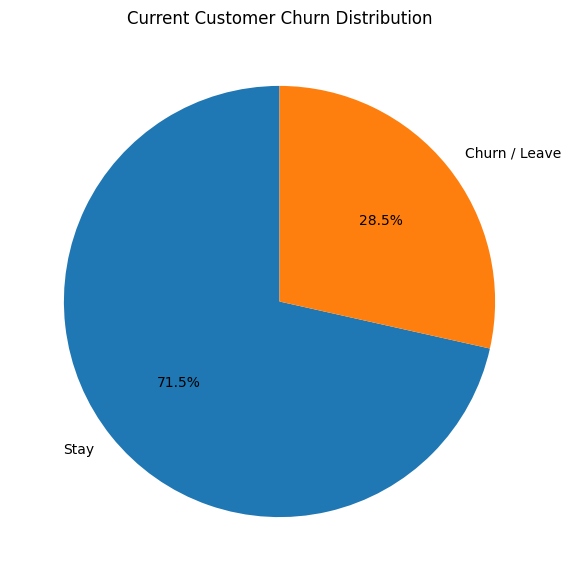

In [391]:
# Visualization
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title('Current Customer Churn Distribution')

plt.show()

Fitly currently has 400 customers, with 114 customers (28.5%) classified as churned and 286 customers (71.5%) remaining active. This 28.5% churn rate establishes the baseline for investigating customer engagement, support activity, and subscription-plan characteristics associated with churn.

##### Question 2: How does customer engagement, measured by activity frequency and activity type, relate to customer churn?

In [392]:
# Merge account_info with user_activity
account_activity_df = pd.merge(
    cleaned_account_info_df[['user_id', 'churn_status']],
    cleaned_user_activity_df,
    on='user_id',
    how='left'
)

account_activity_df.head()

,user_id,churn_status,event_time,event_type
0,10000,Y,2025-08-28,Read article
1,10000,Y,2025-11-13,Read article
2,10000,Y,2025-09-09,Watch video
3,10001,Y,2025-06-22,Read article
4,10002,N,2025-09-17,Read article


In [393]:
activity_summary = (
    account_activity_df
    .groupby(['user_id', 'churn_status'])
    .agg(
        activity_frequency=('event_type', 'count'),
        unique_activity_types=('event_type', 'nunique')
    )
    .reset_index()
)

activity_summary.head()

,user_id,churn_status,activity_frequency,unique_activity_types
0,10000,Y,3,2
1,10001,Y,1,1
2,10002,N,1,1
3,10003,N,1,1
4,10004,N,4,2


In [394]:
engagement_churn_summary = (
    activity_summary
    .groupby('churn_status')
    .agg(
        avg_activity_frequency=('activity_frequency', 'mean'),
        median_activity_frequency=('activity_frequency', 'median'),
        avg_unique_activity_types=('unique_activity_types', 'mean'),
        median_unique_activity_types=('unique_activity_types', 'median')
    )
    .reset_index()
)

engagement_churn_summary

,churn_status,avg_activity_frequency,median_activity_frequency,avg_unique_activity_types,median_unique_activity_types
0,N,1.412587,1.0,1.223776,1.0
1,Y,0.359649,0.0,0.324561,0.0


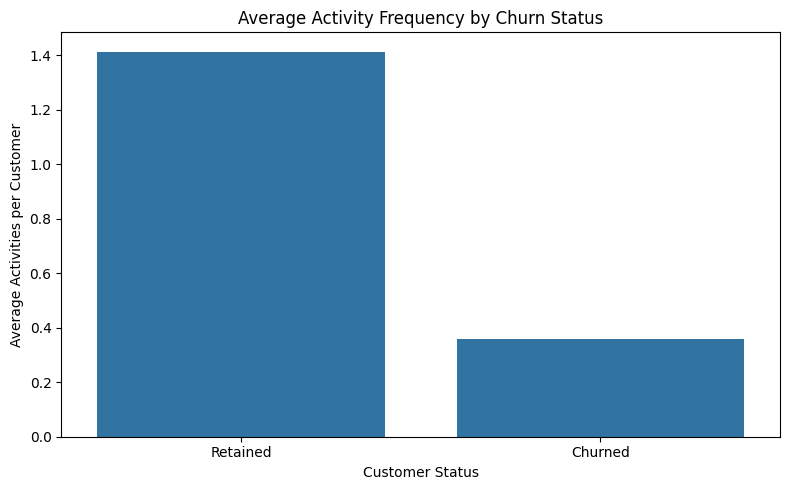

In [395]:
plot_data = (
    activity_summary
    .groupby('churn_status')['activity_frequency']
    .mean()
    .reset_index()
)

plot_data['churn_status'] = plot_data['churn_status'].map({
    'N': 'Retained',
    'Y': 'Churned'
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_data,
    x='churn_status',
    y='activity_frequency',
    order=['Retained', 'Churned']
)

plt.title('Average Activity Frequency by Churn Status')
plt.xlabel('Customer Status')
plt.ylabel('Average Activities per Customer')

plt.tight_layout()
plt.show()

In [396]:
# Analyze activity type
activity_type_churn = (
    account_activity_df
    .groupby(['churn_status', 'event_type'])
    .size()
    .reset_index(name='activity_count')
)

activity_type_churn

,churn_status,event_type,activity_count
0,N,Read article,108
1,N,Share workout,88
2,N,Track workout,107
3,N,Watch video,101
4,Y,Read article,17
5,Y,Share workout,4
6,Y,Track workout,1
7,Y,Watch video,19


<Figure size 1000x600 with 0 Axes>

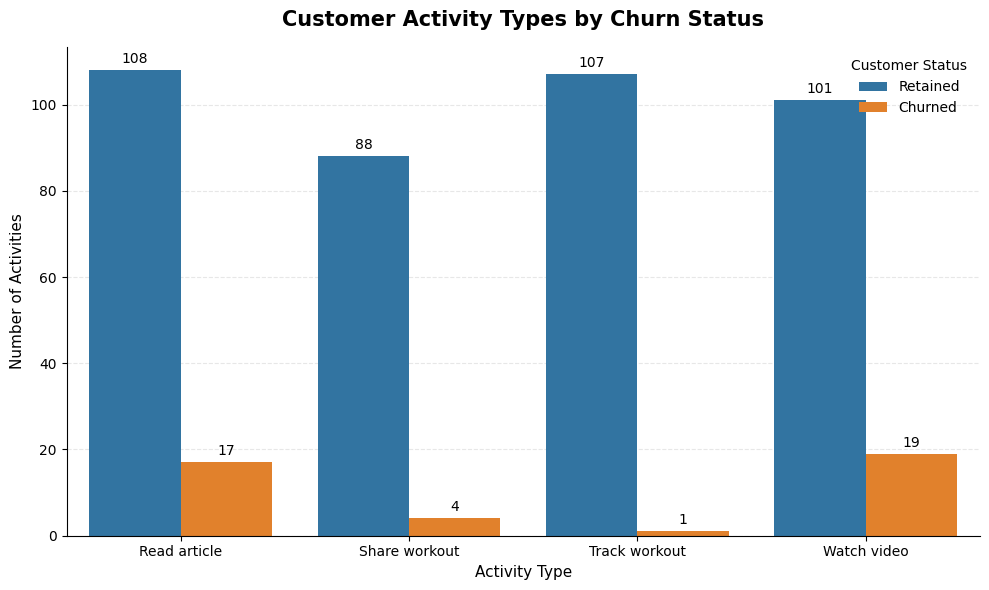

In [398]:
plt.figure(figsize=(10, 6))

# Create a copy for visualization
plot_data = activity_type_churn.copy()

# Rename churn status for readability
plot_data['churn_status'] = plot_data['churn_status'].map({
    'N': 'Retained',
    'Y': 'Churned'
})

# Define the desired activity order
activity_order = [
    'Read article',
    'Share workout',
    'Track workout',
    'Watch video'
]

# Create the chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_data,
    x='event_type',
    y='activity_count',
    hue='churn_status',
    order=activity_order,
    hue_order=['Retained', 'Churned']
)

# Title and labels
plt.title(
    'Customer Activity Types by Churn Status',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel('Activity Type', fontsize=11)
plt.ylabel('Number of Activities', fontsize=11)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=10
    )

# Improve appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Legend
plt.legend(
    title='Customer Status',
    frameon=False
)

plt.tight_layout()
plt.show()

The activity-type analysis shows that retained customers had substantially more recorded engagement across all four activity types than churned customers. Among retained customers, Read Article (108), Track Workout (107), and Watch Video (101) were the most frequently recorded activities, followed by Share Workout (88). In comparison, churned customers recorded fewer activities across every category, with Watch Video (19) and Read Article (17) being the most common, while Share Workout (4) and Track Workout (1) were less frequent. Overall, the results indicate that churned customers had lower recorded engagement across all activity types. However, because the number of retained customers is larger than the number of churned customers, these raw activity counts should be interpreted as differences in engagement volume rather than direct evidence that a specific activity causes or predicts churn.

##### Question 3: How does customer support activity, including ticket frequency and resolution time, relate to customer churn?

In [399]:
# Merge account_info with customer_support

account_customer_support = pd.merge(
    cleaned_account_info_df[['user_id', 'churn_status']],
    cleaned_customer_support_df,
    on='user_id',
    how='left'
)

account_customer_support.head()

,user_id,churn_status,ticket_time,channel,topic,resolution_time_hours
0,10000,Y,2025-08-27,Email,Other,22.40
1,10000,Y,2025-07-27,Chat,Account,23.77
2,10000,Y,2025-10-21,Email,Billing,18.17
3,10001,Y,2025-10-08,Email,Other,26.44
4,10001,Y,2025-07-30,Phone,Billing,10.44


In [400]:
support_customer_summary = (
    account_customer_support
    .groupby(['user_id', 'churn_status'])
    .agg(
        ticket_frequency=('ticket_time', 'count'),
        avg_resolution_time=('resolution_time_hours', 'mean')
    )
    .reset_index()
    .round(2)
)

support_customer_summary.head()

,user_id,churn_status,ticket_frequency,avg_resolution_time
0,10000,Y,3,21.45
1,10001,Y,4,17.54
2,10002,N,3,6.43
3,10003,N,1,2.19
4,10004,N,4,8.54


In [240]:
support_churn_summary = (
    support_customer_summary
    .groupby('churn_status')
    .agg(
        avg_ticket_frequency=('ticket_frequency', 'mean'),
        median_ticket_frequency=('ticket_frequency', 'median'),
        avg_resolution_time=('avg_resolution_time', 'mean'),
        median_resolution_time=('avg_resolution_time', 'median')
    )
    .reset_index()
    .round(2)
)

support_churn_summary

,churn_status,avg_ticket_frequency,median_ticket_frequency,avg_resolution_time,median_resolution_time
0,N,2.0,2.0,7.0,7.0
1,Y,2.0,2.0,19.0,19.0


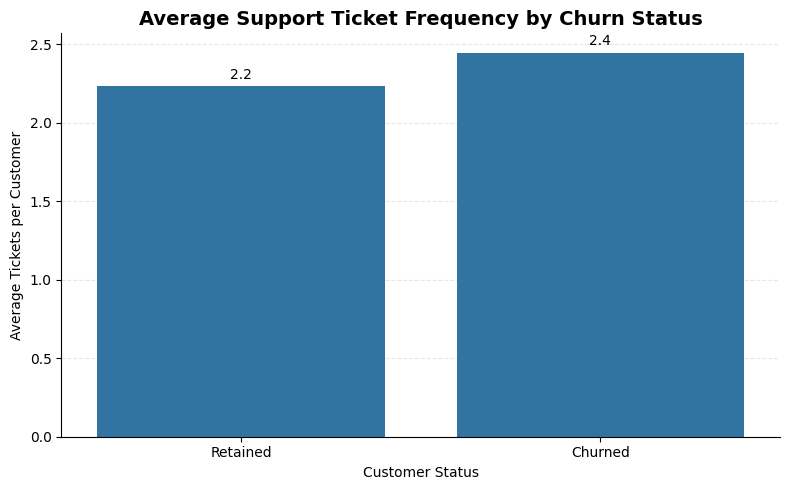

In [401]:
import matplotlib.pyplot as plt
import seaborn as sns

ticket_plot = (
    support_customer_summary
    .groupby('churn_status')['ticket_frequency']
    .mean()
    .reset_index()
)

ticket_plot['churn_status'] = ticket_plot['churn_status'].map({
    'N': 'Retained',
    'Y': 'Churned'
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=ticket_plot,
    x='churn_status',
    y='ticket_frequency',
    order=['Retained', 'Churned']
)

plt.title(
    'Average Support Ticket Frequency by Churn Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Status')
plt.ylabel('Average Tickets per Customer')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

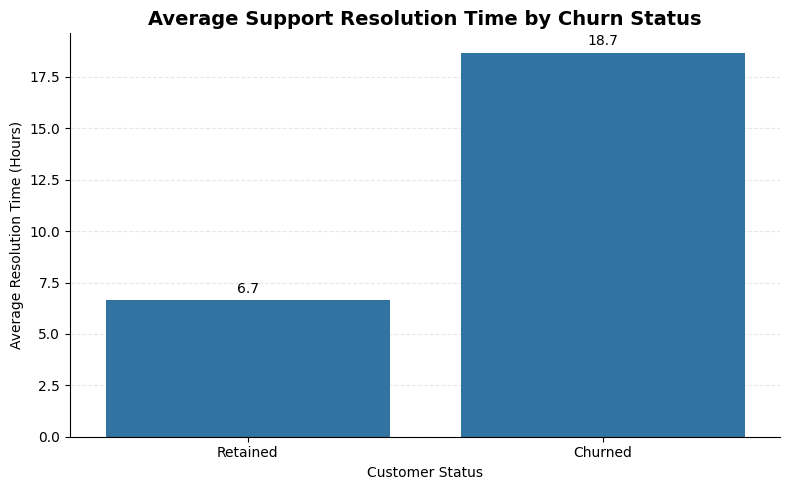

In [402]:
resolution_plot = (
    support_customer_summary
    .groupby('churn_status')['avg_resolution_time']
    .mean()
    .reset_index()
)

resolution_plot['churn_status'] = resolution_plot['churn_status'].map({
    'N': 'Retained',
    'Y': 'Churned'
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=resolution_plot,
    x='churn_status',
    y='avg_resolution_time',
    order=['Retained', 'Churned']
)

plt.title(
    'Average Support Resolution Time by Churn Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Status')
plt.ylabel('Average Resolution Time (Hours)')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Customer support ticket frequency is similar between retained and churned customers, with both groups averaging and having a median of 2 tickets per customer. However, resolution time shows a clear difference. Churned customers had an average resolution time of 19 hours, compared with 7 hours for retained customers. This indicates that longer support resolution times are associated with customer churn, while the number of support tickets alone does not show a clear difference between the two groups.

Overall, the analysis suggests that support resolution time may be a more relevant churn-related indicator than ticket frequency. However, this result shows an association rather than causation, so further analysis of support topics and customer issues would be useful.

##### Question 4: How does customer churn vary across subscription plans and plan price levels?

In [403]:
plan_churn = (
    cleaned_account_info_df
    .groupby('plan')
    .agg(
        customers=('user_id', 'nunique'),
        churned=('churn_status', lambda x: (x == 'Y').sum())
    )
    .reset_index()
)

plan_churn['churn_rate'] = (
    plan_churn['churned'] /
    plan_churn['customers'] * 100
)

plan_churn = plan_churn.sort_values(
    'churn_rate',
    ascending=False
)

plan_churn.round(2)

,plan,customers,churned,churn_rate
2,Free,105,43,40.95
1,Enterprise,92,24,26.09
0,Basic,118,28,23.73
3,Pro,85,19,22.35


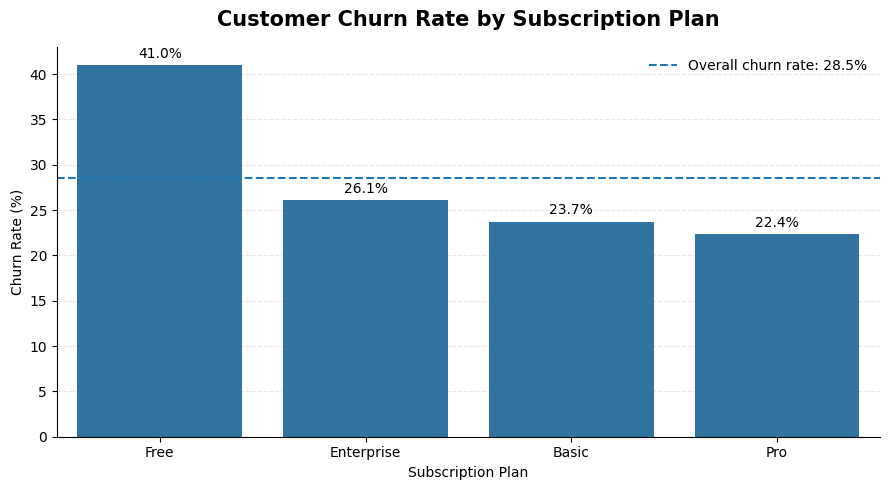

In [404]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plan_churn,
    x='plan',
    y='churn_rate',
    order=plan_churn['plan']
)

plt.title(
    'Customer Churn Rate by Subscription Plan',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

# Overall churn benchmark
overall_churn_rate = (
    cleaned_account_info_df['churn_status']
    .eq('Y')
    .mean() * 100
)

plt.axhline(
    overall_churn_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Overall churn rate: {overall_churn_rate:.1f}%'
)

plt.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [407]:
# Analyze churn by price level
cleaned_account_info_df['price_level'] = pd.cut(
    cleaned_account_info_df['plan_list_price'],
    bins=[-1, 0, 30, 75, float('inf')],
    labels=['Free', 'Low', 'Medium', 'High']
)

In [408]:
price_churn = (
    cleaned_account_info_df
    .groupby('price_level')
    .agg(
        customers=('user_id', 'nunique'),
        churned=('churn_status', lambda x: (x == 'Y').sum())
    )
    .reset_index()
)

price_churn['churn_rate'] = (
    price_churn['churned'] /
    price_churn['customers'] * 100
)

price_churn = price_churn.sort_values(
    'churn_rate',
    ascending=False
)

price_churn.round(2)

/tmp/ipykernel_2661/1794985321.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('price_level')


,price_level,customers,churned,churn_rate
0,Free,105,43,40.95
3,High,101,25,24.75
1,Low,118,28,23.73
2,Medium,76,18,23.68


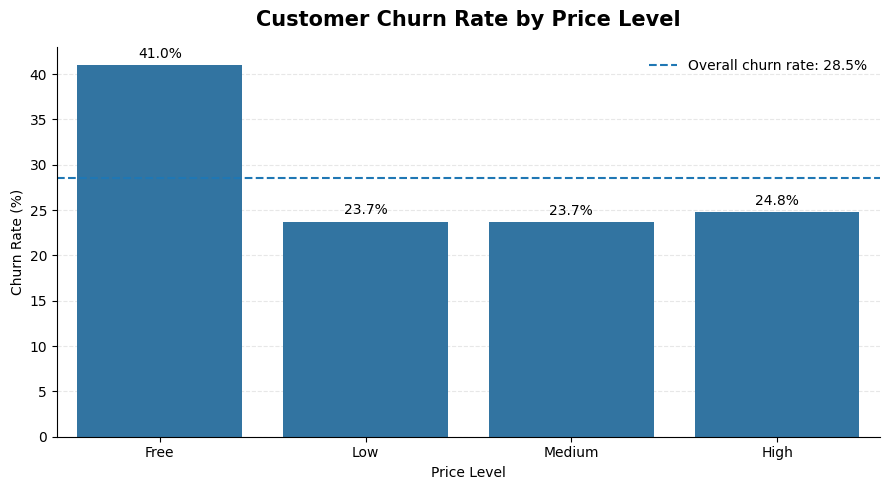

In [409]:
price_order = [
    'Free',
    'Low',
    'Medium',
    'High'
]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=price_churn,
    x='price_level',
    y='churn_rate',
    order=price_order
)

plt.title(
    'Customer Churn Rate by Price Level',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel('Price Level')
plt.ylabel('Churn Rate (%)')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.axhline(
    overall_churn_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Overall churn rate: {overall_churn_rate:.1f}%'
)

plt.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Customer churn varies across subscription plans. The Free plan has the highest churn rate at 40.95%, followed by Enterprise at 26.09%, Basic at 23.73%, and Pro at 22.35%. The overall customer churn rate is 28.5%, meaning that the Free plan is notably above the overall level, while the paid plans are relatively close to or below the overall rate.

The price-level analysis shows a similar pattern. Free customers have a churn rate of 40.95%, compared with 23.73% for Low, 23.68% for Medium, and 24.75% for High price levels. This suggests that the main difference is between Free and paid customers rather than a consistent increase or decrease in churn as price increases.

Overall, Free-plan customers show the highest observed churn, while churn rates across paid price levels are relatively similar. These results indicate that subscription type and price level are relevant dimensions for further churn analysis, but they should be considered together with customer engagement and support activity.

##### Question 5: What combinations of engagement, support activity, and subscription characteristics are associated with higher customer churn?

## Conclusion & Recommendation

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation